## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd
from TNB_tools.spectra import rotary_power_spectra
import gsw


In [2]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
# # MAC
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# DELL
# vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\mackenzie\\Documents\\Research\\PhD\\TNB_tools\\MastersThesis\\tnbd_2018_vel_bot_1093.nc'

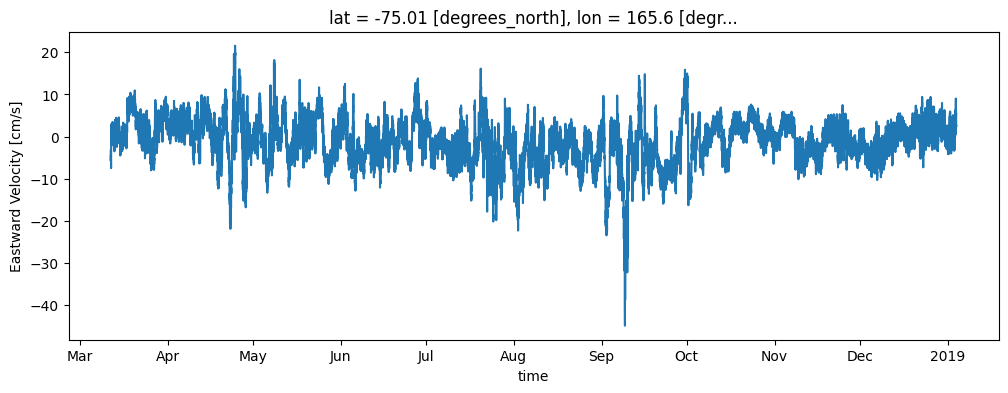

In [3]:
vel.u.plot(figsize=(12,4))

In [4]:
f = gsw.f(-75)
# intertial frequency [cpd]
f_inertial = np.abs(f) * 86400 / (2*np.pi)

In [5]:
f

-0.0001408728441353982

In [6]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 1024

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [7]:
# Chi - squared CI workflow 
freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

Text(0.38, 1.02, 'K1')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/88943626.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


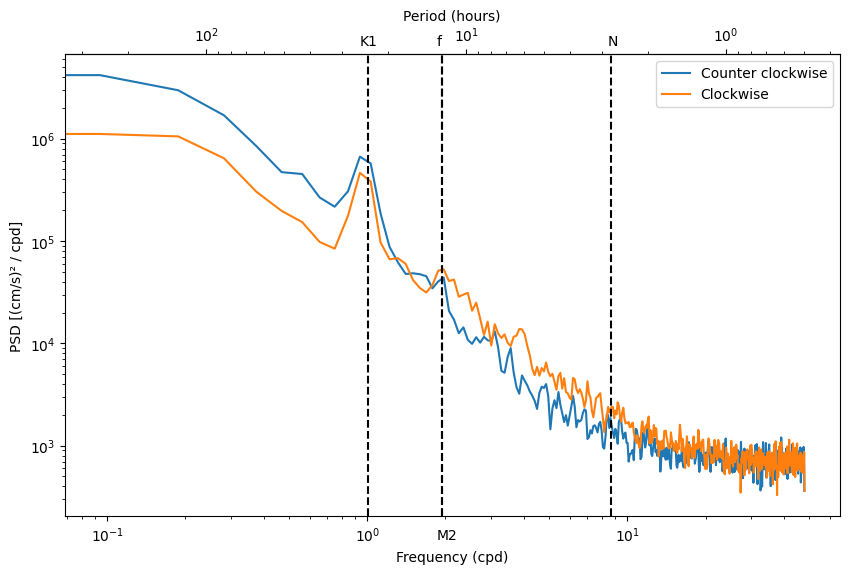

In [8]:
fig = plt.figure(figsize=(10,6))
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
# plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k',label='M2',ls='--')
plt.axvline(1.0027, color='k',label='K1',ls='--')
plt.axvline(1e-4*86400, color='k',label='N',ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

Text(0.38, 1.02, 'K1')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2558768422.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


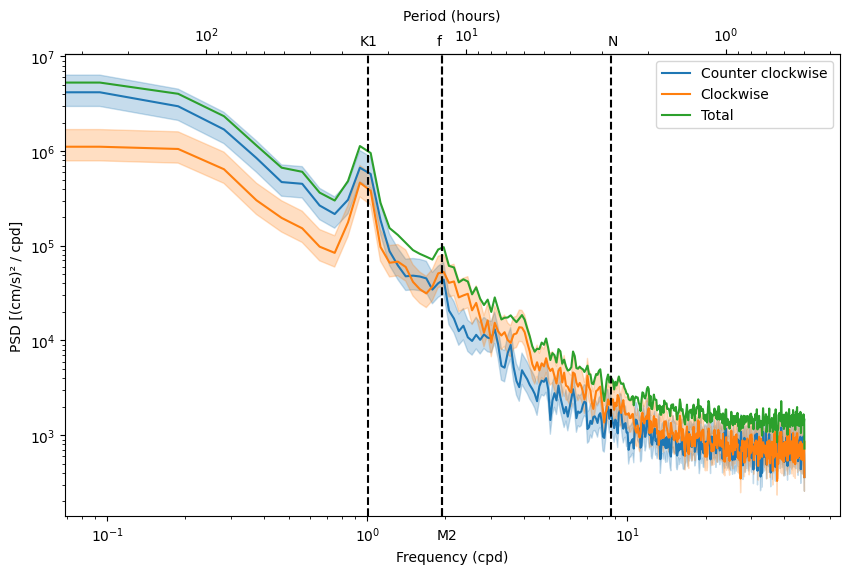

In [9]:
# compute spectra + CI first
# freq, Suu, Svv, Cuv = auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)

# dof, L = dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = spectra_chi2_ci(S_cw, dof)

fig = plt.figure(figsize=(10,6))

freq_cpd = freq * 86400  # compute once, reuse for lines + shading

l1, = plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.fill_between(freq_cpd, S_ccw_lo, S_ccw_hi, color=l1.get_color(), alpha=0.25)

l2, = plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.fill_between(freq_cpd, S_cw_lo, S_cw_hi, color=l2.get_color(), alpha=0.25)

plt.loglog(freq_cpd, (S_ccw + S_cw), label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k', label='M2', ls='--')
plt.axvline(1.0027, color='k', label='K1', ls='--')
plt.axvline(1e-4*86400, color='k', label='N', ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

In [10]:
S_total = S_ccw + S_cw

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2797038303.py:17: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


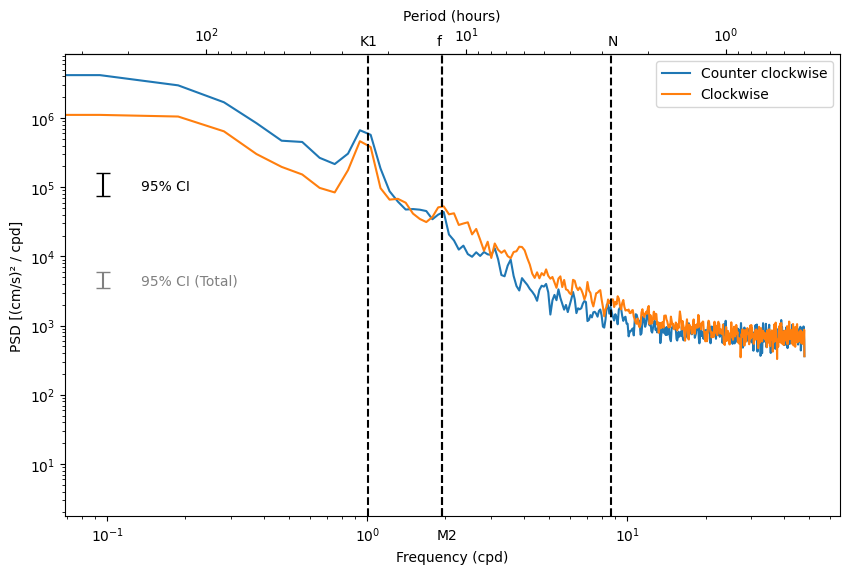

In [11]:
fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

In [12]:
# calculate rotary coefficient and ellipse orientation 
Cr = rotary_power_spectra.rotary_coefficient(S_ccw,S_cw)

In [13]:
sigma = np.arange(10e-2, 10e1, 0.01)
Cr_theory = rotary_power_spectra.rotary_coefficient_theory(sigma,-f_inertial)

In [14]:
f_inertial

1.937140660071021

In [15]:
Cr_theory

array([-0.10297055, -0.11320442, -0.12342033, ..., -0.03873989,
       -0.03873602, -0.03873215])

In [16]:
theta = rotary_power_spectra.ellipse_orientation(Suu,Svv,Cuv)

Text(0.5, 0, 'Freqeuncy [cpd]')

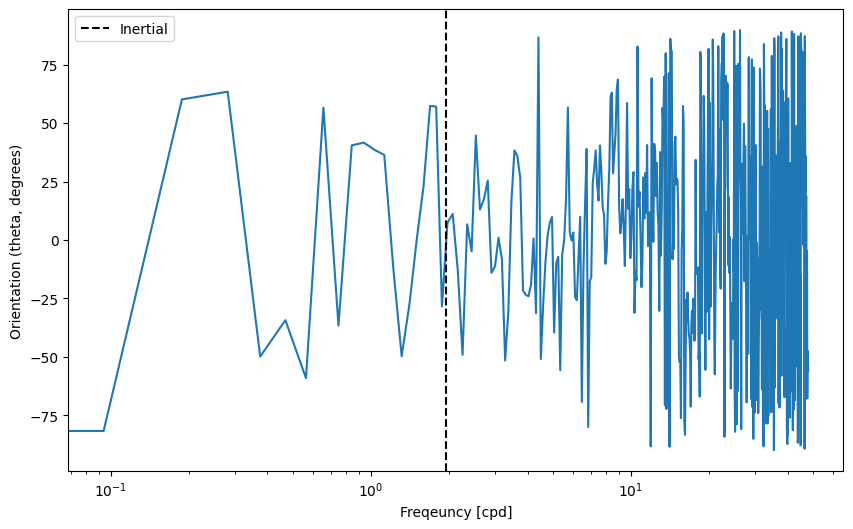

In [17]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, theta)

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Orientation (theta, degrees)')
plt.xlabel('Freqeuncy [cpd]')

Text(0.5, 0, 'Freqeuncy [cpd]')

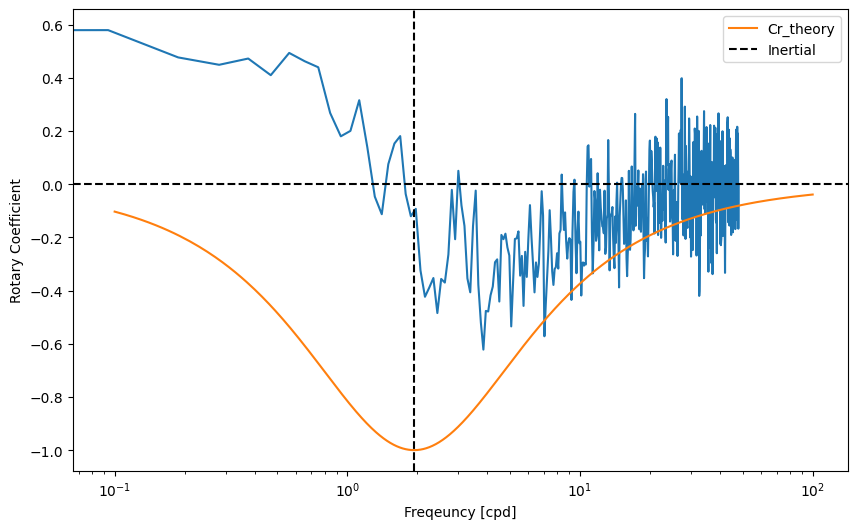

In [18]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, Cr)
plt.semilogx(sigma, Cr_theory,label='Cr_theory')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axhline(0, color='k', ls='--')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Rotary Coefficient')
plt.xlabel('Freqeuncy [cpd]')

### Seasonal Spectra 

In [19]:
# time slices for seasonal averages 
MAM = slice('2018-03','2018-05')
JJA = slice('2018-06','2018-08')
SON = slice('2018-09','2018-11')
DJF = slice('2018-12','2019-01')  # note only december data here 



In [20]:
MAM_subset = vel.sel(time=MAM)
JJA_subset = vel.sel(time=JJA)
SON_subset = vel.sel(time=SON)
DJF_subset = vel.sel(time=DJF)

In [21]:
len(MAM_subset.time), len(JJA_subset.time), len(SON_subset.time), len(DJF_subset.time)

(7776, 8832, 8736, 3266)

In [22]:
nperseg = len(DJF_subset.time)//2

In [23]:
nperseg

1633

In [24]:
2 ** int(np.log2(nperseg))

1024

In [25]:
nperseg = 2 ** int(np.log2(nperseg))

In [26]:
nperseg

1024

In [27]:
# # MAM SPECTRA 
# freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

# dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

# S_total = S_ccw + S_cw

In [28]:
%matplotlib widget

Text(0.5, 1.0, 'MAM Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/1163513702.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


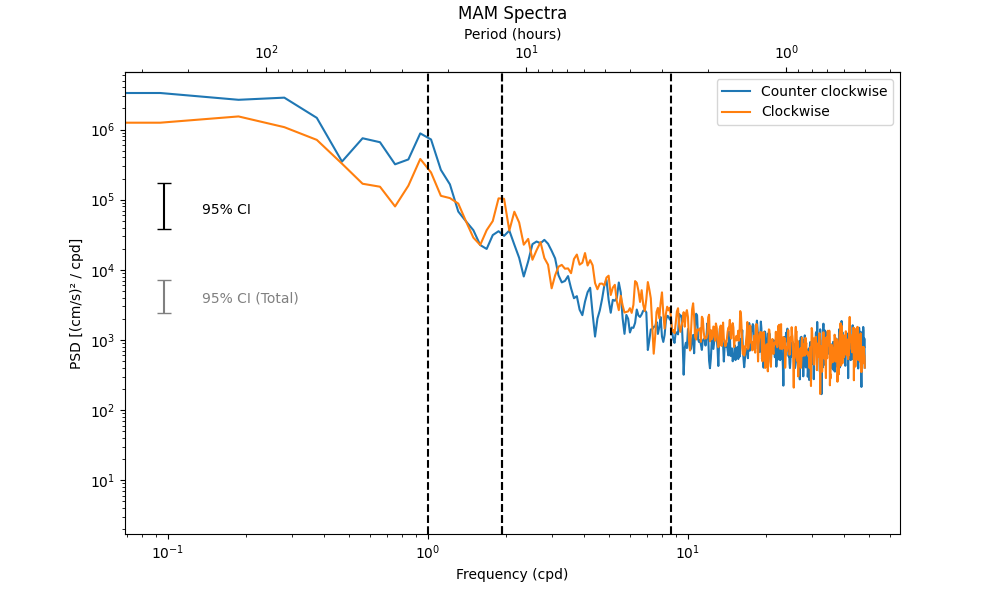

In [29]:
# -------------------- MAM SPECTRA --------------------------------
# nperseg = len(MAM_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('MAM Spectra')

Text(0.5, 1.0, 'JJA Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/137673942.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


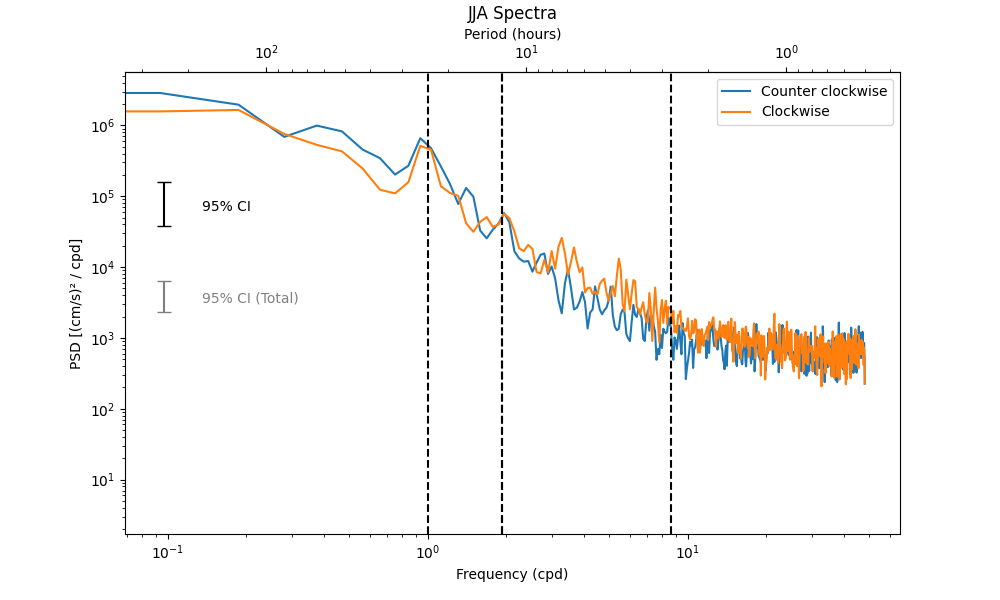

In [30]:
# -------------------- JJA SPECTRA --------------------------------
# nperseg = len(JJA_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(JJA_subset.u, JJA_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(JJA_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('JJA Spectra')

Text(0.5, 1.0, 'SON Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2146110324.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


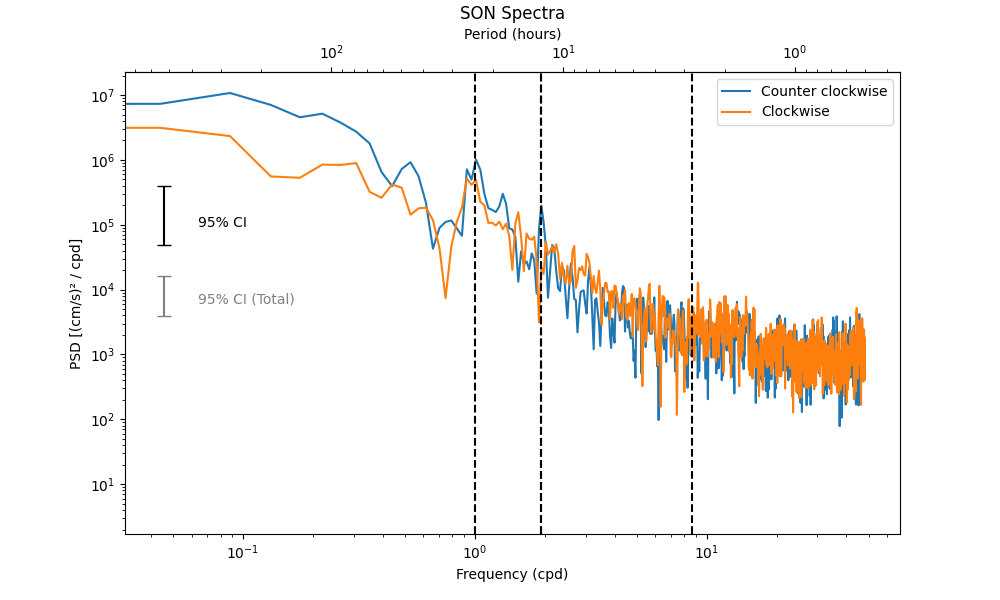

In [31]:
# -------------------- SON SPECTRA --------------------------------
nperseg = len(SON_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(SON_subset.u, SON_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(SON_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('SON Spectra')

Text(0.5, 1.0, 'DJF Spectra')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_98788/2722115822.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


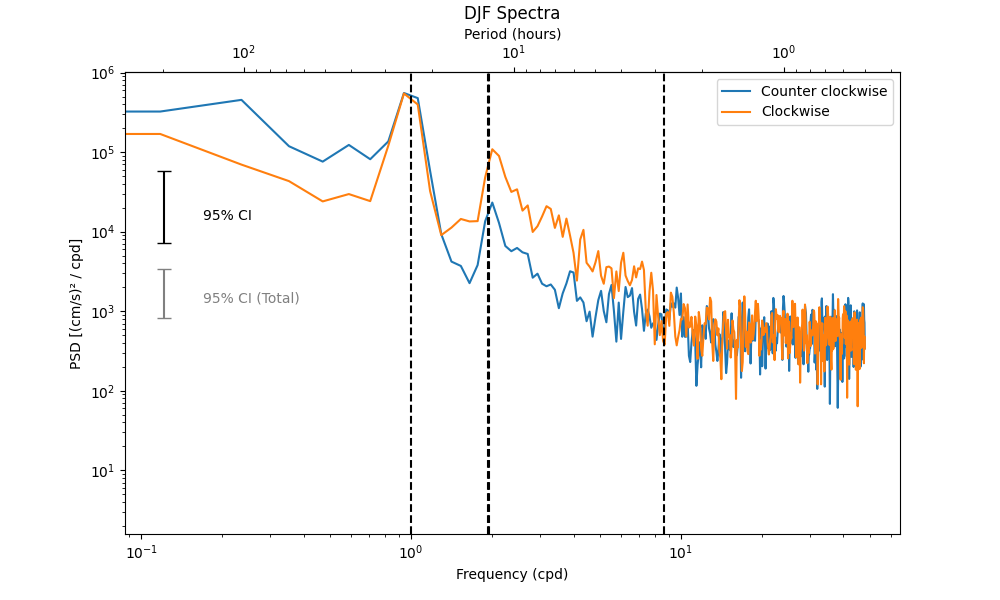

In [32]:
# -------------------- DJF SPECTRA --------------------------------
nperseg = len(DJF_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(DJF_subset.u, DJF_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(DJF_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('DJF Spectra')

In [33]:
dof

8.0

In [34]:
welch?

Signature:
welch(
    x,
    fs=1.0,
    window='hann',
    nperseg=None,
    noverlap=None,
    nfft=None,
    detrend='constant',
    return_onesided=True,
    scaling='density',
    axis=-1,
    average='mean',
)
Docstring:
Estimate power spectral density using Welch's method.

Welch's method [1]_ computes an estimate of the power spectral
density by dividing the data into overlapping segments, computing a
modified periodogram for each segment and averaging the
periodograms.

Parameters
----------
x : array_like
    Time series of measurement values
fs : float, optional
    Sampling frequency of the `x` time series. Defaults to 1.0.
window : str or tuple or array_like, optional
    Desired window to use. If `window` is a string or tuple, it is
    passed to `get_window` to generate the window values, which are
    DFT-even by default. See `get_window` for a list of windows and
    required parameters. If `window` is array_like it will be used
    directly as the window and its lengt

### All Moorings 

In [3]:
# MAC 
moorings = xr.open_datatree('/Users/mackenzie/Documents/Research/PhD/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [3]:
# LOAD DATA - 30 MIN DATA 
# LOAD IN INTERMEDIATE DATASETS DELL - 30 MIN AVERAGED DATA 
TNBD_ctd_top = xr.open_dataset('data/TNBD_ctd_top_30min.nc')
TNBD_ctd_bot = xr.open_dataset('data/TNBD_ctd_bot_30min.nc')
TNBD_vel_top = xr.open_dataset('data/TNBD_vel_top_30min.nc')
TNBD_vel_bot = xr.open_dataset('data/TNBD_vel_bot_30min.nc')

DITD_ctd_top = xr.open_dataset('data/DITD_ctd_top_30min.nc')
DITD_ctd_bot = xr.open_dataset('data/DITD_ctd_bot_30min.nc')
DITD_vel_top = xr.open_dataset('data/DITD_vel_top_30min.nc')
DITD_vel_bot = xr.open_dataset('data/DITD_vel_bot_30min.nc')      # sensor cut out in june 2018

D_ctd_top = xr.open_dataset('data/D_ctd_top_30min.nc')
D_ctd_mid = xr.open_dataset('data/D_ctd_mid_30min.nc')
# D_ctd_bot = D_ctd_bot.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out in 2017

# D_vel_top = D_vel_top.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out end of 2017
D_vel_mid = xr.open_dataset('data/D_vel_mid_30min.nc')
D_vel_bot = xr.open_dataset('data/D_vel_bot_30min.nc')

In [4]:
# load in DITD and D data - MAC
# DITD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/vel_1100.nc')

# TNBD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# moorings = xr.open_datatree('/Users/mackenzie/Documents/Research/PhD/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [5]:
# Load in data - DELL 

# TNBD_vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")

# DITD_vel = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/vel_1100.nc')

# moorings = xr.open_datatree('/Users/mblan/Documents/research/TNB_tools/examples/TNB_Moorings_DataTree.nc')

In [6]:
# fix DITD time - should save this change permenantly later
# DITD_vel['time'] = DITD_vel.time - pd.Timedelta(12,'h')

In [7]:
# rename variables in DITD velocity dataset 
# DITD_vel = DITD_vel.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1121,
#     'lat':-75.28,
#     'lon':164.1
# })
# # rename variables in DITD velocity dataset 
# DITD_vel_bot = DITD_vel_bot.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1218,
#     'lat':-75.28,
#     'lon':164.1
# })

TNBD sampling interval is 15 min. DITD sampling interval is 10 min. D sampling interval is 30 min

In [8]:
# DITD_vel['u'] = DITD_vel.u * 100
# DITD_vel['v'] = DITD_vel.v * 100

In [9]:
# estimate rotary power spectra for each mooring 

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# from TNB_tools.spectra import rotary_power_spectra
from TNB_tools.spectra.rotary_power_spectra import (
    auto_cross_spectra,
    rotary_components,
    rotary_coefficient,
    dof_welch,
    chi2_ci_multiplier,
    add_ci_bracket,
)

# Mooring registry — update fs once you confirm sampling intervals
# from ds.time.diff('time').median()
moorings = {
    'TNBD': {'ds': TNBD_vel_bot, 'fs': 1/1800,  'color': 'steelblue', 'label': 'TNBD'},
    'DITD': {'ds': DITD_vel_top, 'fs': 1/1800,  'color': 'tomato',    'label': 'DITD'},
    'D':    {'ds': D_vel_bot,    'fs': 1/1800,  'color': 'seagreen',  'label': 'D'},
}

# Confirm sampling intervals
for name, m in moorings.items():
    dt = m['ds'].time.diff('time').median().values / np.timedelta64(1, 's')
    print(f"{name}: dt = {dt:.0f} s  (fs = {1/dt:.6f} Hz)")

TNBD: dt = 1800 s  (fs = 0.000556 Hz)
DITD: dt = 1800 s  (fs = 0.000556 Hz)
D: dt = 1800 s  (fs = 0.000556 Hz)


In [11]:
14064/16

879.0

In [46]:
moorings['TNBD']['fs']

0.0005555555555555556

In [38]:
# nperseg fixed across all moorings so frequency resolution is comparable.
# Chosen so even the shortest record (D, 17520 samples) gets ~8 segments.
# D:    17520 // 8 = 2190 -> round to 2048
# TNBD: 28610 // 2048 = 13 segments, dof = 26
# DITD: 42912 // 2048 = 20 segments, dof = 40
# D:    17520 // 2048 =  8 segments, dof = 16
NPERSEG = 879

spectra_full = {}

for name, m in moorings.items():
    ds   = m['ds']
    fs   = m['fs']
    u    = ds['u'].values
    v    = ds['v'].values
    n    = len(u)

    freq, Suu, Svv, Cuv = auto_cross_spectra(
        u, v, fs=fs, nperseg=NPERSEG, noverlap=0
    )
    S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)
    Cr           = rotary_coefficient(S_ccw, S_cw)
    dof, L       = dof_welch(n, NPERSEG, noverlap=0)
    f_lo, f_hi   = chi2_ci_multiplier(dof, ci=95)

    spectra_full[name] = {
        'freq':  freq * 86400,   # convert to cpd
        'Suu' : Suu,
        'Svv' : Svv,
        'Cuv' : Cuv,
        'S_ccw': S_ccw,
        'S_cw':  S_cw,
        'Cr':    Cr,
        'dof':   dof,
        'L':     L,
        'f_lo':  f_lo,
        'f_hi':  f_hi,
    }
    print(f"{name}: n={n}, L={L}, dof={dof}, f_lo={f_lo:.2f}, f_hi={f_hi:.2f}")

TNBD: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75
DITD: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75
D: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75


In [86]:
# --------------------- CORRECTED FREQUENCY UNITS TO PRESERVE VARIANCE ---------------------------------
NPERSEG = 879

spectra_full = {}

for name, m in moorings.items():
    ds   = m['ds']
    fs   = m['fs']       # Hz
    u    = ds['u'].values
    v    = ds['v'].values
    n    = len(u)

    freq, Suu, Svv, Cuv = auto_cross_spectra(
        u, v, fs=fs, nperseg=NPERSEG, noverlap=0
    )
    S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)
    Cr           = rotary_coefficient(S_ccw, S_cw)
    dof, L       = dof_welch(n, NPERSEG, noverlap=0)
    f_lo, f_hi   = chi2_ci_multiplier(dof, ci=95)

    spectra_full[name] = {
        'freq':  freq * 86400,      # Hz -> cpd
        'Suu':   Suu / 86400,       # per-Hz -> per-cpd (keeps integral invariant)
        'Svv':   Svv / 86400,
        'Cuv':   Cuv / 86400,       # cross-spectrum needs the same rescaling
        'S_ccw': S_ccw / 86400,     # rotary components too - they're linear in Suu/Svv/Cuv
        'S_cw':  S_cw / 86400,
        'Cr':    Cr,                # ratio of two PSDs - the 86400 cancels, leave as-is
        'dof':   dof,
        'L':     L,
        'f_lo':  f_lo,
        'f_hi':  f_hi,
    }
    print(f"{name}: n={n}, L={L}, dof={dof}, f_lo={f_lo:.2f}, f_hi={f_hi:.2f}")

TNBD: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75
DITD: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75
D: n=14064, L=16, dof=32, f_lo=0.65, f_hi=1.75


In [87]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\2966429699.py:55: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\2966429699.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


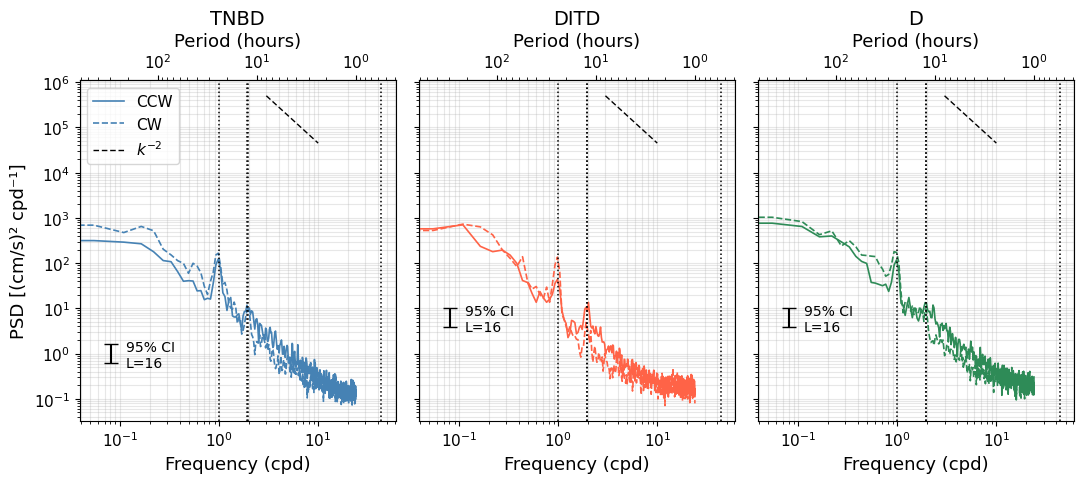

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

# Reference lines — inertial freq at TNB latitude (~-74.9°S) and M2 tidal
import gsw
lat      = -74.9
f_iner   = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)   # cpd
f_M2     = 1.9322                                        # cpd
f_diurn  = 1.0                                           # cpd
N = 43.5 # cpd 

for ax, (name, sp) in zip(axes, spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.loglog(freq, sp['S_ccw'], color=color,  label='CCW', linewidth=1.2)
    ax.loglog(freq, sp['S_cw'],  color=color,  label='CW',  linewidth=1.2,
              linestyle='--')

    # Reference frequency lines
    ax.axvline(f_iner,  color='k',  linestyle=':',  linewidth=1.1,)
    ax.axvline(f_M2,    color='k', linestyle=':',  linewidth=1.1, )
    ax.axvline(f_diurn, color='k',   linestyle=':',  linewidth=1.1,)
    ax.axvline(N,color='k',linestyle=':', linewidth=1.1,)

    add_ci_bracket(ax, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k', x_frac=0.1, y_frac=0.3)



    # --- spectral slopes ---
    # Define a frequency range over which to draw the slopes
    # Adjust f_lo_slope and f_hi_slope to position the lines on your plot
    slopes = [
    # {'exp': -3,    'label': r'$k^{-3}$',   'f_range': [2, 10],  'anchor': 1e6,  'color': 'r'},
    # {'exp': -5/3,  'label': r'$k^{-5/3}$', 'f_range': [3, 15],  'anchor': 5e2,  'color': 'cyan'},
    {'exp': -2,    'label': r'$k^{-2}$',   'f_range': [3, 10],  'anchor': 5e5,  'color': 'k'},
    ]

    for s in slopes:
        f_range = np.array(s['f_range'])
        S_slope = s['anchor'] * (f_range / f_range[0]) ** s['exp']
        ax.loglog(f_range, S_slope,
                color=s['color'],
                linewidth=1.0,
                linestyle=(0, (4, 2)),
                label=s['label'])

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    

    # Secondary period axis
    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')



axes[0].set_ylabel('PSD [(cm/s)² cpd⁻¹]')
axes[0].legend()

# plt.suptitle('Rotary power spectra — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_fullspectra_01.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mblan\AppData\Local\Temp\ipykernel_9032\432100003.py:59: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_9032\432100003.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


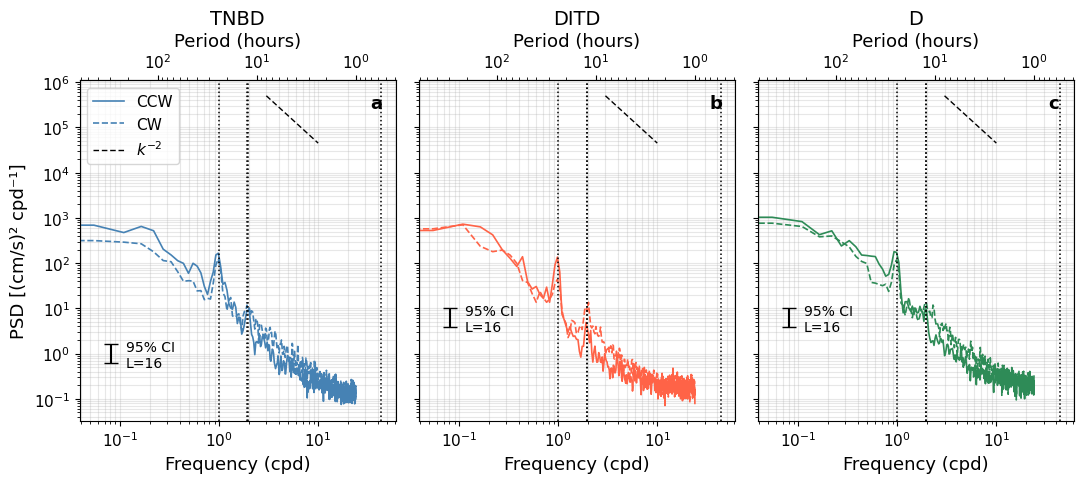

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

# Reference lines — inertial freq at TNB latitude (~-74.9°S) and M2 tidal
import gsw
lat      = -74.9
f_iner   = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)   # cpd
f_M2     = 1.9322                                        # cpd
f_diurn  = 1.0                                           # cpd
N = 43.5 # cpd 

panel_labels = ['a', 'b', 'c']

for ax, (name, sp), label in zip(axes, spectra_full.items(), panel_labels):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.loglog(freq, sp['S_ccw'], color=color,  label='CCW', linewidth=1.2)
    ax.loglog(freq, sp['S_cw'],  color=color,  label='CW',  linewidth=1.2,
              linestyle='--')

    # Reference frequency lines
    ax.axvline(f_iner,  color='k',  linestyle=':',  linewidth=1.1,)
    ax.axvline(f_M2,    color='k', linestyle=':',  linewidth=1.1, )
    ax.axvline(f_diurn, color='k',   linestyle=':',  linewidth=1.1,)
    ax.axvline(N,color='k',linestyle=':', linewidth=1.1,)

    add_ci_bracket(ax, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k', x_frac=0.1, y_frac=0.3)



    # --- spectral slopes ---
    # Define a frequency range over which to draw the slopes
    # Adjust f_lo_slope and f_hi_slope to position the lines on your plot
    slopes = [
    # {'exp': -3,    'label': r'$k^{-3}$',   'f_range': [2, 10],  'anchor': 1e6,  'color': 'r'},
    # {'exp': -5/3,  'label': r'$k^{-5/3}$', 'f_range': [3, 15],  'anchor': 5e2,  'color': 'cyan'},
    {'exp': -2,    'label': r'$k^{-2}$',   'f_range': [3, 10],  'anchor': 5e5,  'color': 'k'},
    ]

    for s in slopes:
        f_range = np.array(s['f_range'])
        S_slope = s['anchor'] * (f_range / f_range[0]) ** s['exp']
        ax.loglog(f_range, S_slope,
                color=s['color'],
                linewidth=1.0,
                linestyle=(0, (4, 2)),
                label=s['label'])

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    # Panel label
    ax.text(0.92, 0.96, label, transform=ax.transAxes,
             fontsize=13, fontweight='bold', va='top', ha='left')

    # Secondary period axis
    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')



axes[0].set_ylabel('PSD [(cm/s)² cpd⁻¹]')
axes[0].legend()

# plt.suptitle('Rotary power spectra — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_fullspectra_01.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\3724191257.py:20: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\3724191257.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


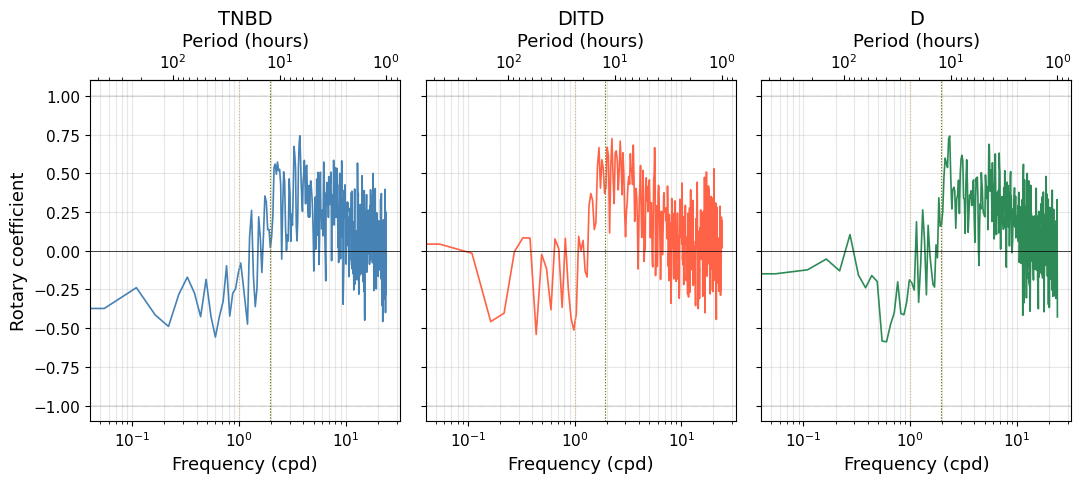

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

for ax, (name, sp) in zip(axes, spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.semilogx(freq, sp['Cr'], color=color, linewidth=1.2)
    ax.axhline(0,  color='k', linewidth=0.5)
    ax.axhline( 1, color='k', linewidth=0.3, linestyle=':')
    ax.axhline(-1, color='k', linewidth=0.3, linestyle=':')
    ax.axvline(f_iner,  color='gray',  linestyle=':', linewidth=0.8)
    ax.axvline(f_M2,    color='olive', linestyle=':', linewidth=0.8)
    ax.axvline(f_diurn, color='tan',   linestyle=':', linewidth=0.8)

    ax.set_ylim(-1.1, 1.1)
    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

axes[0].set_ylabel('Rotary coefficient')
# plt.suptitle('Rotary coefficient — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_rotarycoefficient.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
seasons = {
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
    'DJF': [12],         # December only
}
season_notes = {
    'MAM': 'Mar–May',
    'JJA': 'Jun–Aug',
    'SON': 'Sep–Nov',
    'DJF': 'Dec only',
}
season_order  = ['MAM', 'JJA', 'SON', 'DJF']
mooring_order = ['TNBD', 'DITD', 'D']

spectra_seasonal = {name: {} for name in mooring_order}

for name in mooring_order:
    ds = moorings[name]['ds']
    fs = moorings[name]['fs']

    for season, months in seasons.items():
        seasonal = ds.sel(time=ds.time.dt.month.isin(months))
        n        = len(seasonal.time)

        if n < NPERSEG:
            print(f"{name} {season}: only {n} samples, skipping")
            continue

        u = seasonal['u'].values
        v = seasonal['v'].values

        freq, Suu, Svv, Cuv = auto_cross_spectra(
            u, v, fs=fs, nperseg=NPERSEG, noverlap=0
        )
        S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)
        dof, L       = dof_welch(n, NPERSEG, noverlap=0)
        f_lo, f_hi   = chi2_ci_multiplier(dof, ci=95)

        spectra_seasonal[name][season] = {
            'freq':        freq * 86400,
            'S_ccw':       S_ccw,
            'S_cw':        S_cw,
            'dof':         dof,
            'L':           L,
            'f_lo':        f_lo,
            'f_hi':        f_hi,
            'season_note': season_notes[season],
        }
        print(f"{name} {season}: n={n}, L={L}, dof={dof}")

TNBD MAM: n=3792, L=4, dof=8
TNBD JJA: n=4416, L=5, dof=10
TNBD SON: n=4368, L=4, dof=8
TNBD DJF: n=1488, L=1, dof=2
DITD MAM: n=3792, L=4, dof=8
DITD JJA: n=4416, L=5, dof=10
DITD SON: n=4368, L=4, dof=8
DITD DJF: n=1488, L=1, dof=2
D MAM: n=3792, L=4, dof=8
D JJA: n=4416, L=5, dof=10
D SON: n=4368, L=4, dof=8
D DJF: n=1488, L=1, dof=2


C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\3118049106.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


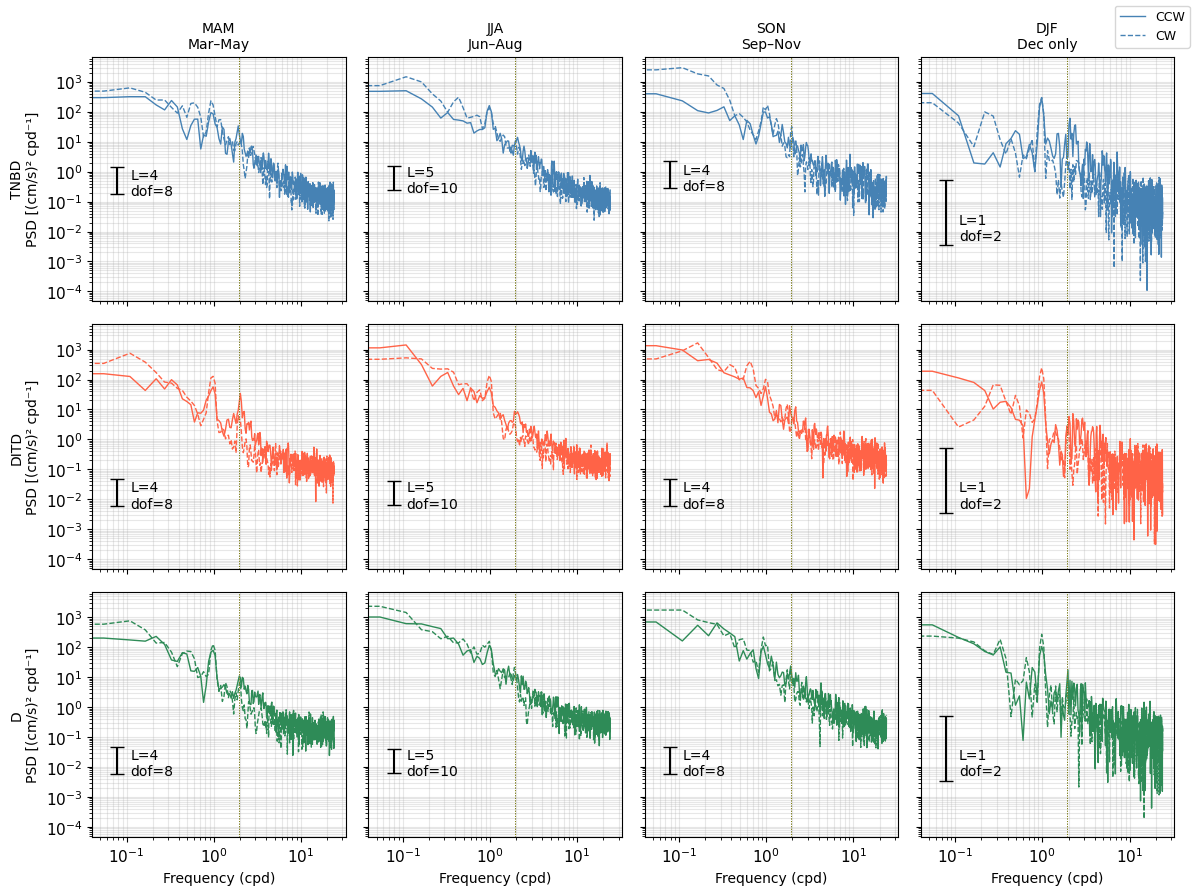

In [17]:
fig, axes = plt.subplots(
    len(mooring_order), len(season_order),
    figsize=(12, 9),
    sharey=True, sharex=True, constrained_layout=True
)

for row, name in enumerate(mooring_order):
    color = moorings[name]['color']
    for col, season in enumerate(season_order):
        ax = axes[row, col]

        if season not in spectra_seasonal[name]:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes,
                    ha='center', va='center', color='gray', fontsize=9)
            ax.set_title(f"{season}\n{season_notes[season]}", fontsize=9)
            continue

        sp   = spectra_seasonal[name][season]
        freq = sp['freq']

        ax.loglog(freq, sp['S_ccw'], color=color, linewidth=1.0, label='CCW')
        ax.loglog(freq, sp['S_cw'],  color=color, linewidth=1.0, label='CW',
                  linestyle='--')

        ax.axvline(f_iner,  color='gray',  linestyle=':', linewidth=0.7)
        ax.axvline(f_M2,    color='olive', linestyle=':', linewidth=0.7)

        add_ci_bracket(ax, sp['f_lo'], sp['f_hi'], color='k',
                       label=f"L={sp['L']}\ndof={sp['dof']}",x_frac=0.1, y_frac=0.3)

        ax.grid(True, which='both', alpha=0.3)

        if row == 0:
            ax.set_title(f"{season}\n{season_notes[season]}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{name}\nPSD [(cm/s)² cpd⁻¹]", fontsize=10)
        if row == len(mooring_order) - 1:
            ax.set_xlabel('Frequency (cpd)', fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)
# plt.suptitle('Seasonal rotary power spectra', y=1.01)
plt.tight_layout()
# plt.show()
# plt.savefig('moorings_2018_seasonalspectra.png', dpi=300, bbox_inches='tight')

C:\Users\mblan\Documents\research\TNB_tools\TNB_tools\spectra\rotary_power_spectra.py:319: RuntimeWarning: invalid value encountered in scalar power
  y_center = ylim[0] * (ylim[1] / ylim[0]) ** y_frac
C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\1572526876.py:61: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\1572526876.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


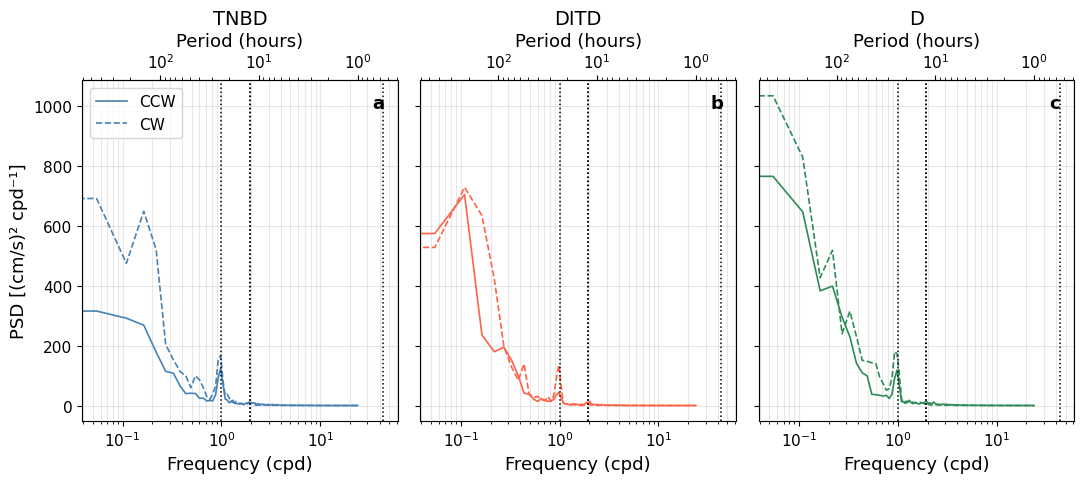

In [18]:
# plot with linear y-axis 

fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True, sharex=True, constrained_layout=True)

# Reference lines — inertial freq at TNB latitude (~-74.9°S) and M2 tidal
import gsw
lat      = -74.9
f_iner   = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)   # cpd
f_M2     = 1.9322                                        # cpd
f_diurn  = 1.0                                           # cpd
N = 43.5 # cpd 

panel_labels = ['a', 'b', 'c']

for ax, (name, sp), label in zip(axes, spectra_full.items(), panel_labels):
    freq  = sp['freq']
    color = moorings[name]['color']

    ax.semilogx(freq, sp['S_ccw'], color=color,  label='CCW', linewidth=1.2)
    ax.semilogx(freq, sp['S_cw'],  color=color,  label='CW',  linewidth=1.2,
              linestyle='--')

    # Reference frequency lines
    ax.axvline(f_iner,  color='k',  linestyle=':',  linewidth=1.1,)
    ax.axvline(f_M2,    color='k', linestyle=':',  linewidth=1.1, )
    ax.axvline(f_diurn, color='k',   linestyle=':',  linewidth=1.1,)
    ax.axvline(N,color='k',linestyle=':', linewidth=1.1,)

    add_ci_bracket(ax, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k', x_frac=0.1, y_frac=0.1)



    # --- spectral slopes ---
    # Define a frequency range over which to draw the slopes
    # Adjust f_lo_slope and f_hi_slope to position the lines on your plot
    slopes = [
    # {'exp': -3,    'label': r'$k^{-3}$',   'f_range': [2, 10],  'anchor': 1e6,  'color': 'r'},
    # {'exp': -5/3,  'label': r'$k^{-5/3}$', 'f_range': [3, 15],  'anchor': 5e2,  'color': 'cyan'},
    # {'exp': -2,    'label': r'$k^{-2}$',   'f_range': [3, 10],  'anchor': 5e5,  'color': 'k'},
    ]

    for s in slopes:
        f_range = np.array(s['f_range'])
        S_slope = s['anchor'] * (f_range / f_range[0]) ** s['exp']
        ax.semilogx(f_range, S_slope,
                color=s['color'],
                linewidth=1.0,
                linestyle=(0, (4, 2)),
                label=s['label'])

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Frequency (cpd)')
    ax.grid(True, which='both', alpha=0.3)

    # Panel label
    ax.text(0.92, 0.96, label, transform=ax.transAxes,
             fontsize=13, fontweight='bold', va='top', ha='left')

    # Secondary period axis
    secax = ax.secondary_xaxis('top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

    # Set x lim 
    # ax.set_xlim(0.5,10)
    # ax.set_ylim(0,350)



axes[0].set_ylabel('PSD [(cm/s)² cpd⁻¹]')
axes[0].legend()

# plt.suptitle('Rotary power spectra — full record', y=1.02)
plt.tight_layout()
# plt.savefig('moorings_2018_fullspectra_01.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
%matplotlib widget

C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\2037599104.py:48: RuntimeWarning: divide by zero encountered in divide
  'top', functions=(lambda f: 24/f, lambda t: 24/t))


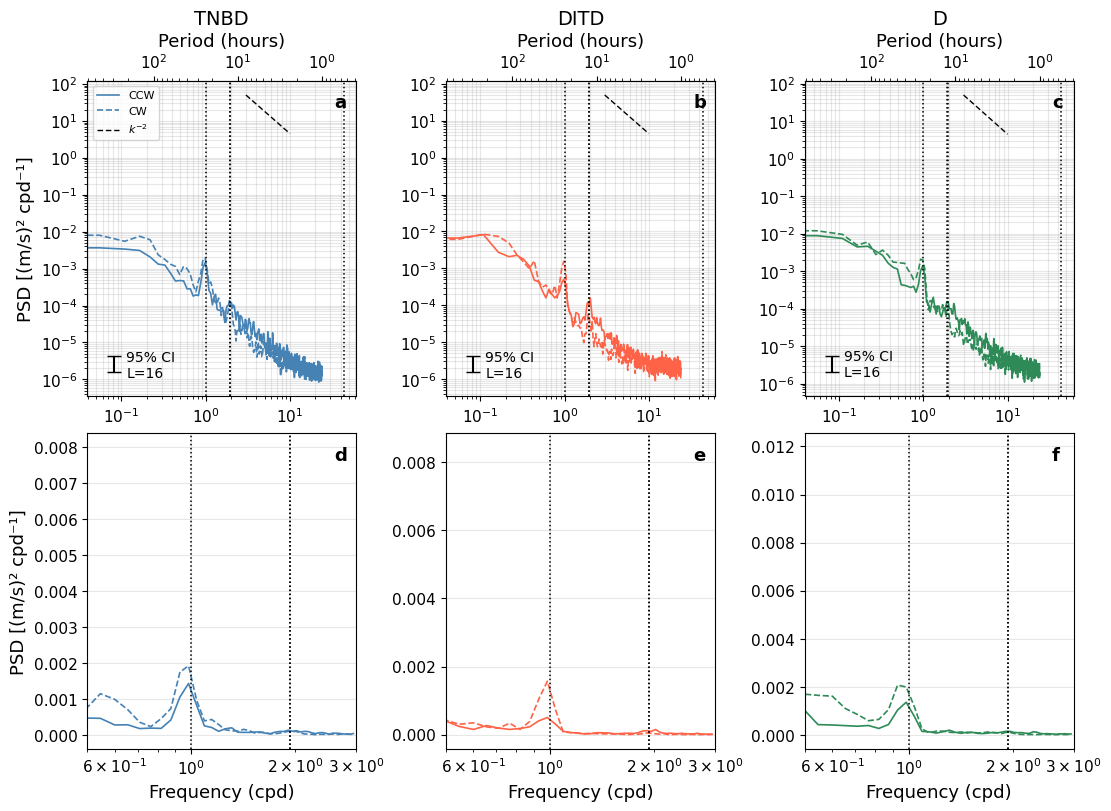

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(11, 8), constrained_layout=True)

import gsw
lat     = -74.9
f_iner  = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)
f_M2    = 1.9322
f_diurn = 1.0
N       = 43.5

panel_labels = ['a', 'b', 'c', 'd', 'e', 'f']

slopes = [
    # {'exp': -3,   'label': r'$k^{-3}$',   'f_range': [2, 10], 'anchor': 1e6, 'color': 'r'},
    # {'exp': -5/3, 'label': r'$k^{-5/3}$', 'f_range': [3, 15], 'anchor': 5e2, 'color': 'cyan'},
    {'exp': -2,   'label': r'$k^{-2}$',   'f_range': [3, 10], 'anchor': 5e1, 'color': 'k'},
]

for col, (name, sp) in enumerate(spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    # ---- top row: log-log ----
    ax_top = axes[0, col]

    ax_top.loglog(freq, sp['S_ccw'], color=color, linewidth=1.2, label='CCW')
    ax_top.loglog(freq, sp['S_cw'],  color=color, linewidth=1.2, label='CW',
                  linestyle='--')

    for fv in [f_iner, f_M2, f_diurn, N]:
        ax_top.axvline(fv, color='k', linestyle=':', linewidth=1.1)

    add_ci_bracket(ax_top, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k',
                   x_frac=0.1, y_frac=0.15, log_y=True)

    for s in slopes:
        f_range = np.array(s['f_range'])
        S_slope = s['anchor'] * (f_range / f_range[0]) ** s['exp']
        ax_top.loglog(f_range, S_slope, color=s['color'], linewidth=1.0,
                      linestyle=(0, (4, 2)), label=s['label'])

    ax_top.set_title(moorings[name]['label'])
    ax_top.grid(True, which='both', alpha=0.3)
    ax_top.text(0.92, 0.96, panel_labels[col], transform=ax_top.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='left')

    secax = ax_top.secondary_xaxis(
        'top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

    # ---- bottom row: linear y, zoomed to tidal band ----
    ax_bot = axes[1, col]

    # Mask to tidal band only for cleaner linear plot
    tidal_mask = (freq >= 0) & (freq <= 3)

    ax_bot.semilogx(freq[tidal_mask], sp['S_ccw'][tidal_mask],
                color=color, linewidth=1.2, label='CCW')
    ax_bot.semilogx(freq[tidal_mask], sp['S_cw'][tidal_mask],
                color=color, linewidth=1.2, label='CW', linestyle='--')


    # ax_bot.semilogx(freq, sp['S_ccw'],
    #             color=color, linewidth=1.2, label='CCW')
    # ax_bot.semilogx(freq, sp['S_cw'],
    #             color=color, linewidth=1.2, label='CW', linestyle='--')

    for fv in [f_iner, f_M2, f_diurn]:
        ax_bot.axvline(fv, color='k', linestyle=':', linewidth=1.1)

    # add_ci_bracket(ax_bot, sp['f_lo'], sp['f_hi'],
    #                label=f"95% CI\nL={sp['L']}", color='k',
    #                x_frac=0.1, y_frac=0.15, log_y=False)

    ax_bot.set_xlim(0.5, 3.0)
    # ax_bot.set_ylim(0,200)
    ax_bot.set_xlabel('Frequency (cpd)')
    ax_bot.grid(True, alpha=0.3)
    ax_bot.text(0.92, 0.96, panel_labels[col + 3], transform=ax_bot.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='left')

# y-axis labels on left column only
axes[0, 0].set_ylabel('PSD [(m/s)² cpd⁻¹]')
axes[1, 0].set_ylabel('PSD [(m/s)² cpd⁻¹]')

# shared legend from top-left panel
axes[0, 0].legend(fontsize=8)

# plt.savefig('moorings_2018_fullspectra_6panel_notzoomed.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mblan\AppData\Local\Temp\ipykernel_23084\2193500661.py:50: RuntimeWarning: divide by zero encountered in divide
  'top', functions=(lambda f: 24/f, lambda t: 24/t))


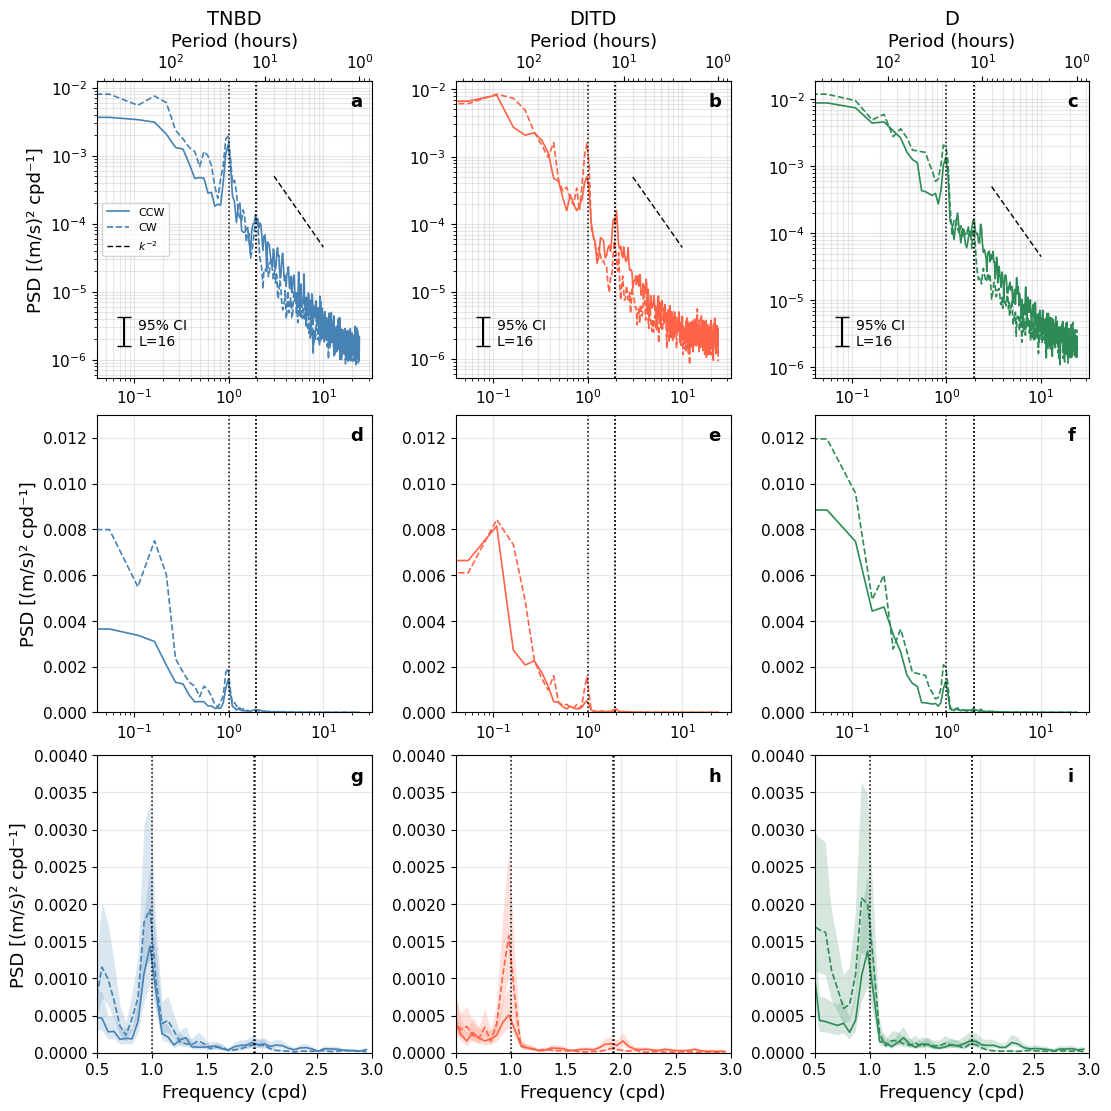

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11), constrained_layout=True)

import gsw
lat     = -74.9
f_iner  = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)
f_M2    = 1.9322
f_diurn = 1.0
N       = 43.5

panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

slopes = [
    {'exp': -2,   'label': r'$k^{-2}$',   'f_range': [3, 10], 'anchor': 5e-4, 'color': 'k'},
]

for col, (name, sp) in enumerate(spectra_full.items()):
    freq  = sp['freq']
    color = moorings[name]['color']

    # CI multiplicative factors for this mooring's segmentation, reused
    # across all three rows
    f_lo, f_hi = chi2_ci_multiplier(sp['dof'], ci=95)

    # ---- row 0: log-log ----
    ax_top = axes[0, col]

    ax_top.loglog(freq, sp['S_ccw'], color=color, linewidth=1.2, label='CCW')
    ax_top.loglog(freq, sp['S_cw'],  color=color, linewidth=1.2, label='CW',
                  linestyle='--')

    for fv in [f_iner, f_M2, f_diurn]:
        ax_top.axvline(fv, color='k', linestyle=':', linewidth=1.1)

    add_ci_bracket(ax_top, sp['f_lo'], sp['f_hi'],
                   label=f"95% CI\nL={sp['L']}", color='k',
                   x_frac=0.1, y_frac=0.15, log_y=True)

    for s in slopes:
        f_range = np.array(s['f_range'])
        S_slope = s['anchor'] * (f_range / f_range[0]) ** s['exp']
        ax_top.loglog(f_range, S_slope, color=s['color'], linewidth=1.0,
                      linestyle=(0, (4, 2)), label=s['label'])

    ax_top.set_title(moorings[name]['label'])
    ax_top.grid(True, which='both', alpha=0.3)
    ax_top.text(0.92, 0.96, panel_labels[col], transform=ax_top.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='left')

    secax = ax_top.secondary_xaxis(
        'top', functions=(lambda f: 24/f, lambda t: 24/t))
    secax.set_xlabel('Period (hours)')

    # ---- row 1: linear y, log x, full frequency range, CI bracket ----
    ax_mid = axes[1, col]

    ax_mid.semilogx(freq, sp['S_ccw'], color=color, linewidth=1.2, label='CCW')
    ax_mid.semilogx(freq, sp['S_cw'],  color=color, linewidth=1.2, label='CW',
                     linestyle='--')

    ax_mid.set_ylim(0,0.013)

    for fv in [f_iner, f_M2, f_diurn]:
        ax_mid.axvline(fv, color='k', linestyle=':', linewidth=1.1)

    ax_mid.grid(True, alpha=0.3)
    ax_mid.text(0.92, 0.96, panel_labels[col + 3], transform=ax_mid.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='left')

    # add_ci_bracket(ax_mid, f_lo, f_hi,
    #                 label=f"95% CI\nL={sp['L']}", color='k',
    #                 x_frac=0.1, y_frac=0.85, log_y=False)

    # ---- row 2: linear x, linear y, tidal zoom, CI shading ----
    ax_bot = axes[2, col]

    tidal_mask = (freq >= 0) & (freq <= 3)
    f_z   = freq[tidal_mask]
    ccw_z = sp['S_ccw'][tidal_mask]
    cw_z  = sp['S_cw'][tidal_mask]

    ax_bot.plot(f_z, ccw_z, color=color, linewidth=1.2, label='CCW')
    ax_bot.plot(f_z, cw_z,  color=color, linewidth=1.2, label='CW',
                linestyle='--')

    ax_bot.fill_between(f_z, ccw_z * f_lo, ccw_z * f_hi,
                         color=color, alpha=0.2, linewidth=0)
    ax_bot.fill_between(f_z, cw_z * f_lo, cw_z * f_hi,
                         color=color, alpha=0.2, linewidth=0)

    for fv in [f_iner, f_M2, f_diurn]:
        ax_bot.axvline(fv, color='k', linestyle=':', linewidth=1.1)

    ax_bot.set_xlim(0.5, 3.0)
    ax_bot.set_ylim(0, 0.004)
    ax_bot.set_xlabel('Frequency (cpd)')
    ax_bot.grid(True, alpha=0.3)
    ax_bot.text(0.92, 0.96, panel_labels[col + 6], transform=ax_bot.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='left')

# y-axis labels on left column only
axes[0, 0].set_ylabel('PSD [(m/s)² cpd⁻¹]')
axes[1, 0].set_ylabel('PSD [(m/s)² cpd⁻¹]')
axes[2, 0].set_ylabel('PSD [(m/s)² cpd⁻¹]')

# shared legend from top-left panel
axes[0, 0].legend(fontsize=8)
# plt.savefig('moorings_2018_fullspectra_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

E_CCW (m²/s²)  E_CW  (m²/s²)  E_total (m²/s²)  \
Mooring Band                                                                   
TNBD    Low-Frequency               0.001014       0.002106         0.003120   
        Diurnal                     0.000255       0.000367         0.000622   
        Semi-diurnal/Inertial       0.000067       0.000044         0.000111   
        High Frequency              0.000131       0.000078         0.000209   
DITD    Low-Frequency               0.001496       0.001949         0.003445   
        Diurnal                     0.000097       0.000214         0.000311   
        Semi-diurnal/Inertial       0.000053       0.000019         0.000072   
        High Frequency              0.000094       0.000063         0.000157   
D       Low-Frequency               0.002096       0.002835         0.004931   
        Diurnal                     0.000238       0.000374         0.000612   
        Semi-diurnal/Inertial       0.000077       0.000056         0.000133   
        High Frequency              0.000163       0.000095         0.000258   

                               CCW fraction  
Mooring Band                                 
TNBD    Low-Frequency                 0.325  
        Diurnal                       0.410  
        Semi-diurnal/Inertial         0.601  
        High Frequency                0.627  
DITD    Low-Frequency                 0.434  
        Diurnal                       0.313  
        Semi-diurnal/Inertial         0.742  
        High Frequency                0.598  
D       Low-Frequency                 0.425  
        Diurnal                       0.388  
        Semi-diurnal/Inertial         0.579  
        High Frequency                0.632

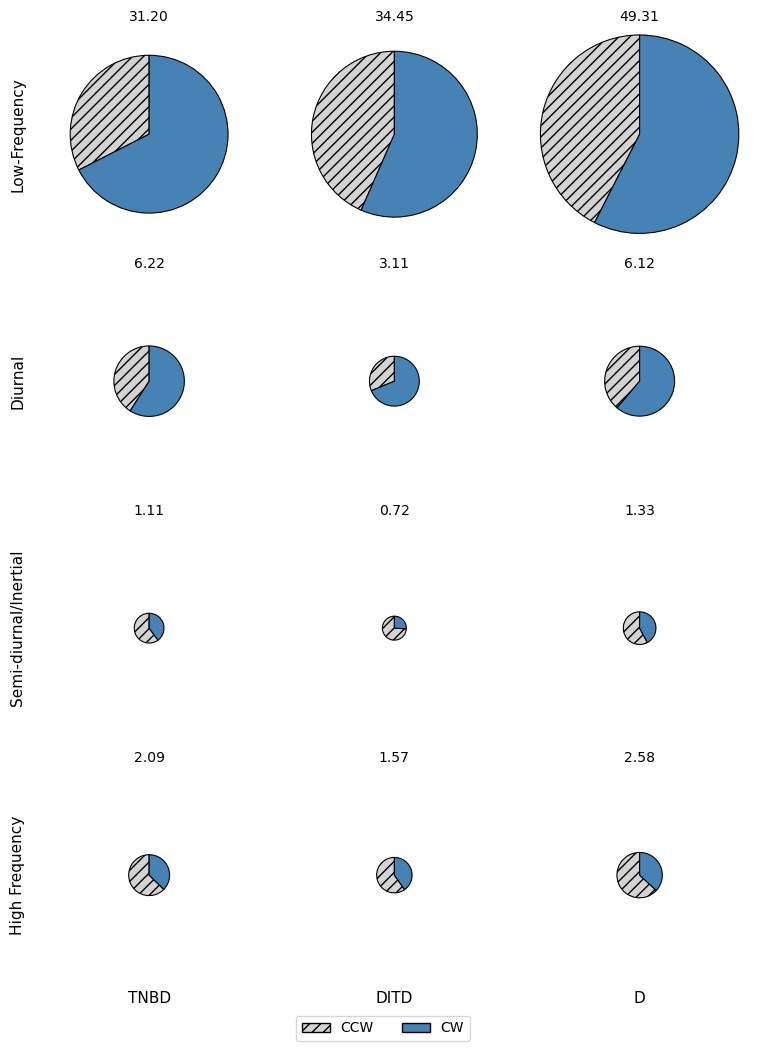

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gsw

# ----- estimate nyquist frequency ------
dt_days = 30 / (60 * 24)   # 30 min in days
fs = 1 / dt_days           # cycles/day
f_nyquist = fs / 2         # = 24.0 cpd for 30-min data

# --- reference frequencies ---
lat     = -74.9
f_diurn = 1.0      # cpd
f_M2    = 1.9322   # cpd
f_iner  = np.abs(gsw.f(lat)) * 86400 / (2 * np.pi)  # cpd, recompute as before
f_nyq   = fs / 2    # 24.0 cpd, from above

# --- frequency bands ---
# freq_bands = {
#     'Sub-inertial':   (0.0,              f_iner * 0.85),
#     # 'Inertial':       (f_iner * 0.85,    f_iner * 1.15),
#     'Diurnal':        (0.85,             1.15),
#     'Semi-diurnal':   (1.85,             2.05),
#     'Super-inertial': (2.05,             N),
# }

freq_bands = {
    'Low-Frequency':        (0.0,             0.85),
    'Diurnal':             (0.85,            1.5),
    'Semi-diurnal/Inertial': (1.5,           2.3),
    'High Frequency':      (2.3,             f_nyq),
}

band_order    = list(freq_bands.keys())
mooring_order = list(spectra_full.keys())

# --- band energy integration ---
def band_energy(freq, S, f_lo, f_hi):
    """Integrate PSD over a frequency band using trapezoidal rule."""
    mask = (freq >= f_lo) & (freq <= f_hi)
    if mask.sum() < 2:
        return 0.0
    return np.trapezoid(S[mask], freq[mask])

# --- compute energy table ---
energy_table = {}
for name, sp in spectra_full.items():
    freq  = sp['freq']
    energy_table[name] = {}
    for band, (f_lo, f_hi) in freq_bands.items():
        E_ccw = band_energy(freq, sp['S_ccw'], f_lo, f_hi)
        E_cw  = band_energy(freq, sp['S_cw'],  f_lo, f_hi)
        energy_table[name][band] = {
            'CCW':   E_ccw,
            'CW':    E_cw,
            'total': E_ccw + E_cw,
        }

# --- print summary table ---
import pandas as pd
rows = []
for name in mooring_order:
    for band in band_order:
        e = energy_table[name][band]
        rows.append({
            'Mooring':         name,
            'Band':            band,
            'E_CCW (m²/s²)':  round(e['CCW'],   6),
            'E_CW  (m²/s²)':  round(e['CW'],    6),
            'E_total (m²/s²)': round(e['total'], 6),
            'CCW fraction':    round(e['CCW'] / e['total'], 3) if e['total'] > 0 else np.nan,
        })
display(pd.DataFrame(rows).set_index(['Mooring', 'Band']))

# --- pie chart figure ---
n_bands    = len(band_order)
n_moorings = len(mooring_order)

fig, axes = plt.subplots(
    n_bands, n_moorings,
    figsize=(2.5 * n_moorings, 2.5 * n_bands),   # smaller per-panel size
    constrained_layout=True,
)

# After the figure is created, tighten the subplot spacing directly
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, hspace=0.05, wspace=0.05)

# E_max for radius scaling — computed before the loop
E_max = max(
    energy_table[name][band]['total']
    for name in mooring_order
    for band in band_order
)

for row, band in enumerate(band_order):
    for col, name in enumerate(mooring_order):
        ax    = axes[row, col]
        e     = energy_table[name][band]
        E_ccw = e['CCW']
        E_cw  = e['CW']
        E_tot = e['total']

        if E_tot == 0:
            ax.text(0.5, 0.5, 'no energy', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='gray')
            ax.axis('off')
            continue

        fracs  = [E_ccw / E_tot, E_cw / E_tot]
        radius = np.sqrt(E_tot / E_max) * 0.9   # area proportional to energy

        wedges, _ = ax.pie(
            fracs,
            startangle=90,
            radius=radius,
            wedgeprops=dict(linewidth=0.8, edgecolor='k'),
            colors=['lightgray', 'steelblue'],
        )
        wedges[0].set_hatch('///')   # CCW = hatched, following caption convention

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Energy label above pie — m²/s² scaled to ×10⁻⁴ for readability
        E_label = E_tot * 10**(4)   # -> units of 10⁻⁴ m²/s²
        ax.set_title(f'{E_label:.2f}', fontsize=10, pad=2)

        # Row labels (band names) on left column
        if col == 0:
            ax.set_ylabel(band, fontsize=11, labelpad=10)

        # Column labels (mooring names) on top row
        if row == 3:
            ax.set_xlabel(moorings[name]['label'], fontsize=11)
            # ax.xaxis.set_label_position('top')

# legend
legend_elements = [
    Patch(facecolor='lightgray', hatch='///', edgecolor='k', label='CCW'),
    Patch(facecolor='steelblue', edgecolor='k',              label='CW'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.04),
)

# plt.suptitle('Band-integrated rotary energy partition', fontsize=12, y=1.01)
# plt.savefig('rotary_energy_pies.png', dpi=300, bbox_inches='tight')
plt.show()

In [93]:
def verify_band_energy_conservation(freq, S, freq_bands, rtol=0.01):
    """
    Check that summed per-band integrated energy matches the energy
    integrated directly over the full [freq_bands lo, freq_bands hi]
    range, to within rtol. Catches gaps/overlaps in freq_bands and
    off-by-one masking errors.
    """
    f_lo_all = min(lo for lo, hi in freq_bands.values())
    f_hi_all = max(hi for lo, hi in freq_bands.values())
    mask_all = (freq >= f_lo_all) & (freq <= f_hi_all)
    E_total_direct = np.trapezoid(S[mask_all], freq[mask_all])

    E_total_summed = sum(
        band_energy(freq, S, lo, hi) for lo, hi in freq_bands.values()
    )

    rel_diff = abs(E_total_direct - E_total_summed) / E_total_direct
    if rel_diff > rtol:
        raise AssertionError(
            f"Band energies don't sum to total: direct={E_total_direct:.6g}, "
            f"summed={E_total_summed:.6g}, rel_diff={rel_diff:.4f} "
            f"(check freq_bands for gaps/overlaps)"
        )
    return E_total_direct, E_total_summed

In [95]:
freq_bands

{'Low-Frequency': (0.0, 0.85),
 'Diurnal': (0.85, 1.5),
 'Semi-diurnal/Inertial': (1.5, 2.3),
 'High Frequency': (2.3, 24.0)}

In [96]:
verify_band_energy_conservation(spectra_full['TNBD']['freq'],spectra_full['TNBD']['S_cw'],freq_bands,)

AssertionError: Band energies don't sum to total: direct=0.00263398, summed=0.00259567, rel_diff=0.0145 (check freq_bands for gaps/overlaps)

In [97]:
verify_band_energy_conservation(spectra_full['DITD']['freq'],spectra_full['DITD']['S_cw'],freq_bands,)

(np.float64(0.002261371582250755), np.float64(0.0022441031780623326))

In [98]:
verify_band_energy_conservation(spectra_full['D']['freq'],spectra_full['D']['S_cw'],freq_bands,)

AssertionError: Band energies don't sum to total: direct=0.00341409, summed=0.00336085, rel_diff=0.0156 (check freq_bands for gaps/overlaps)

In [99]:
def verify_parseval(u, v, freq, Suu, Svv, rtol=0.05):
    """
    Check that integrated PSD variance matches the direct time-domain
    variance (Parseval's theorem), for both u and v. Welch windowing
    and overlap mean this holds only approximately -- expect a few
    percent discrepancy, not exact equality.

    Parameters
    ----------
    u, v : array_like
        Raw (or already-detrended) velocity time series.
    freq : array_like
        Frequency array from auto_cross_spectra / welch.
    Suu, Svv : array_like
        Auto-spectral densities from auto_cross_spectra.
    rtol : float, optional
        Relative tolerance. Default 0.05 (5%), consistent with
        expected Welch windowing/segmentation error -- not a strict
        precision bound.
    """
    u = np.asarray(u) - np.mean(u)
    v = np.asarray(v) - np.mean(v)

    var_u_direct = np.var(u, ddof=0)
    var_v_direct = np.var(v, ddof=0)
    var_u_psd = np.trapezoid(Suu, freq)
    var_v_psd = np.trapezoid(Svv, freq)

    rel_u = abs(var_u_direct - var_u_psd) / var_u_direct
    rel_v = abs(var_v_direct - var_v_psd) / var_v_direct

    print(f"u: direct={var_u_direct:.5f}, PSD={var_u_psd:.5f}, rel_diff={rel_u:.4%}")
    print(f"v: direct={var_v_direct:.5f}, PSD={var_v_psd:.5f}, rel_diff={rel_v:.4%}")

    if rel_u > rtol or rel_v > rtol:
        raise AssertionError(
            f"PSD-integrated variance doesn't match time-domain variance "
            f"within {rtol:.0%}: rel_u={rel_u:.4%}, rel_v={rel_v:.4%}. "
            f"Check detrending consistency, window normalization, or "
            f"whether freq spans the full [0, Nyquist] range."
        )
    return var_u_direct, var_v_direct, var_u_psd, var_v_psd

In [100]:
verify_parseval(TNBD_vel_bot.u.values,TNBD_vel_bot.v.values, spectra_full['TNBD']['freq'], spectra_full['TNBD']['Suu'], spectra_full['TNBD']['Svv'])

u: direct=0.00289, PSD=0.00200, rel_diff=31.0037%
v: direct=0.00331, PSD=0.00213, rel_diff=35.7928%


AssertionError: PSD-integrated variance doesn't match time-domain variance within 5%: rel_u=31.0037%, rel_v=35.7928%. Check detrending consistency, window normalization, or whether freq spans the full [0, Nyquist] range.

In [102]:
verify_parseval(DITD_vel_top.u.values,DITD_vel_top.v.values, spectra_full['DITD']['freq'], spectra_full['DITD']['Suu'], spectra_full['DITD']['Svv'])

u: direct=0.00219, PSD=0.00182, rel_diff=17.0635%
v: direct=0.00245, PSD=0.00220, rel_diff=10.3137%


AssertionError: PSD-integrated variance doesn't match time-domain variance within 5%: rel_u=17.0635%, rel_v=10.3137%. Check detrending consistency, window normalization, or whether freq spans the full [0, Nyquist] range.

In [103]:
verify_parseval(D_vel_bot.u.values,D_vel_bot.v.values, spectra_full['D']['freq'], spectra_full['D']['Suu'], spectra_full['D']['Svv'])

u: direct=0.00403, PSD=0.00316, rel_diff=21.5670%
v: direct=0.00393, PSD=0.00286, rel_diff=27.2353%


AssertionError: PSD-integrated variance doesn't match time-domain variance within 5%: rel_u=21.5670%, rel_v=27.2353%. Check detrending consistency, window normalization, or whether freq spans the full [0, Nyquist] range.

In [104]:
def verify_parseval_segment_consistent(u, v, nperseg, noverlap, freq, Suu, Svv, rtol=0.05):
    """
    Segment-consistent Parseval check: instead of comparing the PSD
    integral to the variance of the globally-detrended series, this
    detrends u/v the same way welch() does internally (per-segment
    constant removal) before computing the "direct" variance -- so
    both sides of the comparison are subject to the same low-frequency
    variance loss, isolating whether any remaining Parseval mismatch
    is due to segment detrending (expected, not a bug) versus
    something else (a real pipeline issue).

    Parameters
    ----------
    u, v : array_like
        Raw (not yet detrended) velocity time series -- the same
        arrays passed into auto_cross_spectra / welch.
    nperseg, noverlap : int
        Must match what was passed to auto_cross_spectra when Suu/Svv
        were generated.
    freq : array_like
        Frequency array from auto_cross_spectra (any consistent units,
        as long as Suu/Svv are PSD-per-that-unit).
    Suu, Svv : array_like
        Auto-spectral densities from auto_cross_spectra.
    rtol : float, optional
        Relative tolerance for the segment-consistent comparison.
        This should be much tighter than a global-mean comparison,
        since we've now controlled for the detrending difference --
        a large gap here would point to something beyond segment
        detrending (units, windowing, missed data, etc).
    """
    u = np.asarray(u)
    v = np.asarray(v)
    n = len(u)
    step = nperseg - noverlap

    # Chop into the same non-overlapping/overlapping segments welch
    # uses internally, remove each segment's own mean (matching
    # detrend='constant'), then treat the concatenation of residuals
    # as the "segment-detrended" direct series.
    starts = range(0, n - nperseg + 1, step)
    u_detrended_segments = []
    v_detrended_segments = []
    for s in starts:
        seg_u = u[s:s+nperseg]
        seg_v = v[s:s+nperseg]
        u_detrended_segments.append(seg_u - seg_u.mean())
        v_detrended_segments.append(seg_v - seg_v.mean())

    u_seg_detrended = np.concatenate(u_detrended_segments)
    v_seg_detrended = np.concatenate(v_detrended_segments)

    var_u_direct_segconsistent = np.var(u_seg_detrended, ddof=0)
    var_v_direct_segconsistent = np.var(v_seg_detrended, ddof=0)

    var_u_psd = np.trapezoid(Suu, freq)
    var_v_psd = np.trapezoid(Svv, freq)

    rel_u = abs(var_u_direct_segconsistent - var_u_psd) / var_u_direct_segconsistent
    rel_v = abs(var_v_direct_segconsistent - var_v_psd) / var_v_direct_segconsistent

    print(f"Segment-consistent check (both sides per-segment-detrended):")
    print(f"  u: direct={var_u_direct_segconsistent:.5f}, PSD={var_u_psd:.5f}, rel_diff={rel_u:.4%}")
    print(f"  v: direct={var_v_direct_segconsistent:.5f}, PSD={var_v_psd:.5f}, rel_diff={rel_v:.4%}")

    if rel_u > rtol or rel_v > rtol:
        print(
            f"  WARNING: still {max(rel_u, rel_v):.2%} off even after controlling for "
            f"segment detrending -- this points to something beyond the expected "
            f"low-frequency loss (check windowing, units, or leftover data issues)."
        )
    else:
        print(
            f"  Segment-detrended variance and PSD integral agree within {rtol:.0%} -- "
            f"confirms the earlier ~30% gap was explained by per-segment mean removal "
            f"suppressing low-frequency variance, not a pipeline bug."
        )

    return var_u_direct_segconsistent, var_v_direct_segconsistent, var_u_psd, var_v_psd

In [105]:
verify_parseval_segment_consistent(
    TNBD_vel_bot.u.values, TNBD_vel_bot.v.values,
    nperseg=NPERSEG, noverlap=0,
    freq=spectra_full['TNBD']['freq'] / 86400,   # back to Hz, matching raw welch scale
    Suu=spectra_full['TNBD']['Suu'] * 86400,      # back to per-Hz, matching that freq
    Svv=spectra_full['TNBD']['Svv'] * 86400,
)

Segment-consistent check (both sides per-segment-detrended):
  u: direct=0.00226, PSD=0.00200, rel_diff=11.5859%
  v: direct=0.00270, PSD=0.00213, rel_diff=21.2982%


(np.float64(0.002258774542995024),
 np.float64(0.002703163826142454),
 np.float64(0.0019970746637823704),
 np.float64(0.0021274394297457404))

In [106]:
verify_parseval_segment_consistent(
    DITD_vel_top.u.values, DITD_vel_top.v.values,
    nperseg=NPERSEG, noverlap=0,
    freq=spectra_full['DITD']['freq'] / 86400,   # back to Hz, matching raw welch scale
    Suu=spectra_full['DITD']['Suu'] * 86400,      # back to per-Hz, matching that freq
    Svv=spectra_full['DITD']['Svv'] * 86400,
)

Segment-consistent check (both sides per-segment-detrended):
  u: direct=0.00174, PSD=0.00182, rel_diff=4.5501%
  v: direct=0.00225, PSD=0.00220, rel_diff=2.3915%
  Segment-detrended variance and PSD integral agree within 5% -- confirms the earlier ~30% gap was explained by per-segment mean removal suppressing low-frequency variance, not a pipeline bug.


(np.float64(0.0017396855725556341),
 np.float64(0.0022529923740859897),
 np.float64(0.001818842447469468),
 np.float64(0.002199111829995789))

In [107]:
verify_parseval_segment_consistent(
    D_vel_bot.u.values, D_vel_bot.v.values,
    nperseg=NPERSEG, noverlap=0,
    freq=spectra_full['D']['freq'] / 86400,   # back to Hz, matching raw welch scale
    Suu=spectra_full['D']['Suu'] * 86400,      # back to per-Hz, matching that freq
    Svv=spectra_full['D']['Svv'] * 86400,
)

Segment-consistent check (both sides per-segment-detrended):
  u: direct=0.00306, PSD=0.00316, rel_diff=3.4081%
  v: direct=0.00302, PSD=0.00286, rel_diff=5.3089%


(np.float64(0.0030591334471694286),
 np.float64(0.0030173861936929887),
 np.float64(0.0031633904584404994),
 np.float64(0.0028571964521144242))

In [79]:
fs = moorings['TNBD']['fs']
u = moorings['TNBD']['ds']['u']
v = moorings['TNBD']['ds']['v']

freq_hann, Suu_hann, Svv_hann, Cuv_hann = auto_cross_spectra(
    u, v, fs=fs, nperseg=NPERSEG, noverlap=0
)
# then rerun with boxcar -- you'll need to expose window as a kwarg in
# auto_cross_spectra if it isn't already, or call welch/csd directly:
from scipy.signal import welch, csd
freq_bc, Suu_bc = welch(u, fs=fs, nperseg=NPERSEG, noverlap=0,
                          detrend='constant', window='boxcar')
_, Svv_bc = welch(v, fs=fs, nperseg=NPERSEG, noverlap=0,
                    detrend='constant', window='boxcar')

In [80]:
verify_parseval_segment_consistent(
    TNBD_vel_bot.u.values, TNBD_vel_bot.v.values,
    nperseg=NPERSEG, noverlap=0,
    freq=freq_hann,   # back to Hz, matching raw welch scale
    Suu=Suu_hann,      # back to per-Hz, matching that freq
    Svv=Svv_hann,
)

Segment-consistent check (both sides per-segment-detrended):
  u: direct=0.00226, PSD=0.00200, rel_diff=11.5859%
  v: direct=0.00270, PSD=0.00213, rel_diff=21.2982%


(np.float64(0.002258774542995024),
 np.float64(0.002703163826142454),
 np.float64(0.0019970746637823704),
 np.float64(0.0021274394297457404))

In [81]:
verify_parseval_segment_consistent(
    TNBD_vel_bot.u.values, TNBD_vel_bot.v.values,
    nperseg=NPERSEG, noverlap=0,
    freq=freq_bc,   # back to Hz, matching raw welch scale
    Suu=Suu_bc,      # back to per-Hz, matching that freq
    Svv=Svv_bc,
)

Segment-consistent check (both sides per-segment-detrended):
  u: direct=0.00226, PSD=0.00226, rel_diff=0.0025%
  v: direct=0.00270, PSD=0.00270, rel_diff=0.0043%
  Segment-detrended variance and PSD integral agree within 5% -- confirms the earlier ~30% gap was explained by per-segment mean removal suppressing low-frequency variance, not a pipeline bug.


(np.float64(0.002258774542995024),
 np.float64(0.002703163826142454),
 np.float64(0.002258718574833571),
 np.float64(0.0027030470998250272))

### Progressive vector diagrams to verify the direction of inertial osciallations

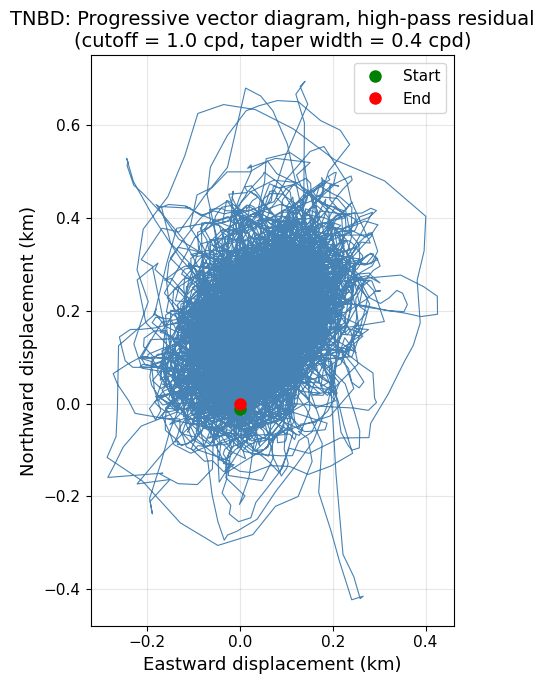

In [117]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_highpass_filter(x, fs, f_cutoff, f_taper_width):
    """
    Frequency-domain high-pass filter with a raised-cosine transition
    band, applied via FFT. See docstring detail: frequencies below
    (f_cutoff - f_taper_width/2) are fully removed, frequencies above
    (f_cutoff + f_taper_width/2) are fully retained, with a smooth
    half-cosine taper in between (avoids ringing from a hard cutoff).
    """
    x = np.asarray(x)
    n = len(x)

    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    f_lo = f_cutoff - f_taper_width / 2
    f_hi = f_cutoff + f_taper_width / 2

    H = np.zeros_like(freqs)
    H[freqs >= f_hi] = 1.0
    taper_mask = (freqs > f_lo) & (freqs < f_hi)
    H[taper_mask] = 0.5 * (1 - np.cos(np.pi * (freqs[taper_mask] - f_lo) / (f_hi - f_lo)))

    X_filtered = X * H
    x_filtered = np.fft.irfft(X_filtered, n=n)
    return x_filtered


# --- load TNBD velocity ---
u = DITD_vel_top.u.values
v = DITD_vel_top.v.values
time = DITD_vel_top.time.values

fs = 48.0  # cpd, 30-min sampling

# Cutoff centered near the diurnal band, tapering from ~0.8 to ~1.2 cpd
# so sub-diurnal / mean-flow variability is removed while the diurnal,
# inertial (f_iner), and semidiurnal (M2) bands are retained.
F_CUTOFF = 1.0
F_TAPER_WIDTH = 0.4

u_hp = cosine_highpass_filter(u, fs, F_CUTOFF, F_TAPER_WIDTH)
v_hp = cosine_highpass_filter(v, fs, F_CUTOFF, F_TAPER_WIDTH)

# --- progressive vector diagram ---
# PVD: cumulative displacement if the water parcel moved at the
# instantaneous (filtered) velocity throughout the record. dt in
# seconds since u, v are in m/s.
dt_seconds = 1800  # 30 min

x_disp = np.cumsum(u_hp) * dt_seconds  # meters
y_disp = np.cumsum(v_hp) * dt_seconds

# convert to km for readability
x_disp_km = x_disp / 1000
y_disp_km = y_disp / 1000

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_disp_km, y_disp_km, color='steelblue', linewidth=0.8)
ax.plot(x_disp_km[0], y_disp_km[0], 'go', markersize=8, label='Start', zorder=5)
ax.plot(x_disp_km[-1], y_disp_km[-1], 'ro', markersize=8, label='End', zorder=5)

ax.set_xlabel('Eastward displacement (km)')
ax.set_ylabel('Northward displacement (km)')
ax.set_title(f'TNBD: Progressive vector diagram, high-pass residual\n'
             f'(cutoff = {F_CUTOFF} cpd, taper width = {F_TAPER_WIDTH} cpd)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

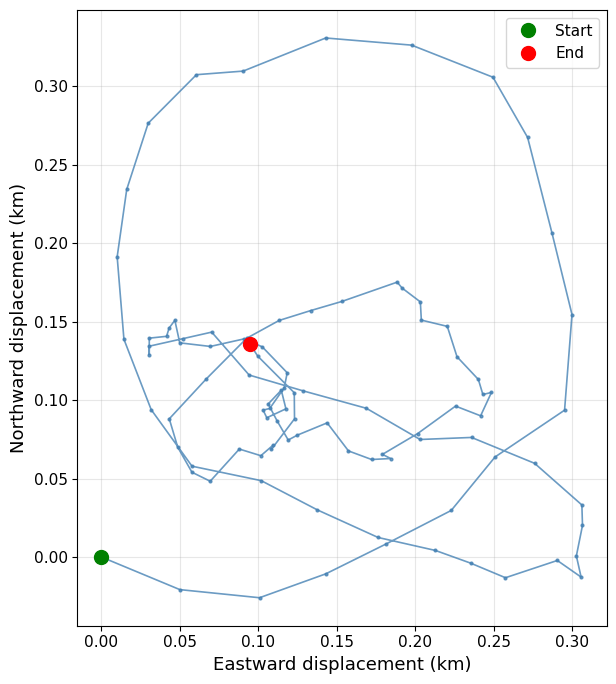

In [118]:
# --- zoom to the first N days to see individual inertial loops ---
N_DAYS = 2
n_samples = int(N_DAYS * 24 * 60 / 30)
skip_samples = int(30 * 24 * 60 / 30)   # skip first 10 days to avoid edge artifact

x_zoom = x_disp_km[skip_samples:skip_samples + n_samples] - x_disp_km[skip_samples]
y_zoom = y_disp_km[skip_samples:skip_samples + n_samples] - y_disp_km[skip_samples]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_zoom, y_zoom, color='steelblue', linewidth=1.2, marker='o',
        markersize=2, alpha=0.8)
ax.plot(x_zoom[0], y_zoom[0], 'go', markersize=10, label='Start', zorder=5)
ax.plot(x_zoom[-1], y_zoom[-1], 'ro', markersize=10, label='End', zorder=5)

ax.set_xlabel('Eastward displacement (km)')
ax.set_ylabel('Northward displacement (km)')
# ax.set_title(f'TNBD: PVD, high-pass residual, first {N_DAYS} days\n'
#              f'(inertial period \u2248 {period_hours:.1f} hr)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### updates / summary 09/01/2026 

Double check the rotary component analysis and found some issues. The CCW and CW definitions were swapped and this was based on how scipy csd function defines the co spectrum through conjugates (gives different signs depending on how it is calculated). I verified the direction of intertial oscialltions by doing a high pass filter to obtain frequencies greater than diurnal and plotting PVDs. The PVDs shows counter clockwise rotations which is consistent with theory in the SH. My power spectra now also show CCW dominance at frequencies greater than inertial. I found my scaling for PSD was off because I never scaled these values when I converted frequency from Hz to cpd. Now the units should  make sense. I went through and check parsevals theorm to make sure variance is preserved. I found that it's necessary to compare variance estimated from segments instead of the full record to be consistent with welch's method. I also found that the Hann window also causes a slight loss in variance but I am keeping this window because if I use a box car then it is more subject to spectral leakage. 

